# MSE-803 Week 4 — Activity 1: Happiness Dashboard and Data Visualisation

Build a simple happiness dashboard from the **cleaned** World Happiness dataset using **Matplotlib** and **Plotly**.

**Tasks**
1. Load and explore the cleaned dataset
2. Identify the three happiest countries (ranking / aggregation)
3. Compare their Happiness Scores with clear visualisations
4. Summarise the Freedom score for the country with the lowest Happiness Score
5. Use both Matplotlib and Plotly

**GitHub:** https://github.com/mdasufian/MSE-803-data-analytics/tree/main/week-4/activity-1

## 1. Setup and load the cleaned dataset

If you see `ModuleNotFoundError: No module named 'plotly'`, run the next cell once to install packages into **this notebook’s kernel**.

In [ ]:
%pip install -q pandas matplotlib plotly
print("Dependencies ready.")

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Show Plotly charts inside the notebook
import plotly.io as pio
# Works in VS Code, JupyterLab, and classic Notebook
pio.renderers.default = "plotly_mimetype+notebook_connected"

DATA_PATH = Path("world_happiness_dataset.csv")
OUTPUT_DIR = Path("outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

print("Libraries loaded.")

/home/abusufian/anaconda3/lib/python3.12/site-packages/pandas/core/computation/expressions.py:23: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


Libraries loaded.


In [2]:
df = pd.read_csv(DATA_PATH)

print(f"File: {DATA_PATH.name}")
print(f"Shape: {df.shape[0]} countries × {df.shape[1]} columns")
print(f"Missing values: {df.isnull().sum().sum()}")
print(f"Columns: {list(df.columns)}")
df.head()

File: world_happiness_dataset.csv
Shape: 20 countries × 8 columns
Missing values: 0
Columns: ['Country', 'Happiness_Score', 'GDP_per_Capita', 'Social_Support', 'Healthy_Life_Expectancy', 'Freedom_to_Make_Choices', 'Generosity', 'Perceptions_of_Corruption']


,Country,Happiness_Score,GDP_per_Capita,Social_Support,Healthy_Life_Expectancy,Freedom_to_Make_Choices,Generosity,Perceptions_of_Corruption
0,Norway,6.25,1.39,0.82,81.6,0.69,0.01,0.71
1,Denmark,3.61,1.27,0.43,66.9,0.48,0.43,0.53
2,Iceland,4.68,0.87,0.54,63.4,0.71,0.41,0.72
3,Switzerland,4.46,0.67,0.57,68.8,0.93,0.32,0.52
4,Finland,6.67,1.55,0.45,75.4,0.58,0.16,0.10


In [3]:
df.describe()

,Happiness_Score,GDP_per_Capita,Social_Support,Healthy_Life_Expectancy,Freedom_to_Make_Choices,Generosity,Perceptions_of_Corruption
count,20.000000,20.000000,20.000000,20.000000,20.000000,20.000000,20.000000
mean,5.171500,1.149000,0.624000,62.290000,0.661000,0.303500,0.503500
std,1.250715,0.304785,0.150382,12.332708,0.227617,0.171196,0.277532
min,3.530000,0.600000,0.430000,41.300000,0.330000,0.010000,0.100000
25%,4.237500,0.907500,0.522500,51.175000,0.472500,0.160000,0.192500
50%,4.995000,1.170000,0.570000,61.350000,0.665000,0.310000,0.525000
75%,6.260000,1.395000,0.772500,73.300000,0.862500,0.415000,0.732500
max,7.340000,1.570000,0.960000,81.600000,1.000000,0.570000,0.860000


## 2. Identify the three happiest countries

Each country appears once, so ranking by `Happiness_Score` (descending) is the aggregation step needed for this task.

In [4]:
top3 = (
    df.sort_values("Happiness_Score", ascending=False)
    .head(3)
    .reset_index(drop=True)[["Country", "Happiness_Score", "Freedom_to_Make_Choices"]]
)

print("Three happiest countries:")
top3

Three happiest countries:


,Country,Happiness_Score,Freedom_to_Make_Choices
0,Canada,7.34,1.00
1,Brazil,6.98,0.98
2,Finland,6.67,0.58


In [5]:
lowest = df.loc[df["Happiness_Score"].idxmin()]
mean_freedom = float(df["Freedom_to_Make_Choices"].mean())

print("Country with the lowest Happiness Score:")
print(f"  Country:                 {lowest['Country']}")
print(f"  Happiness Score:         {lowest['Happiness_Score']:.2f}")
print(f"  Freedom to Make Choices: {lowest['Freedom_to_Make_Choices']:.2f}")
print(f"  Dataset mean Freedom:    {mean_freedom:.2f}")
print(f"  Difference vs mean:      {float(lowest['Freedom_to_Make_Choices']) - mean_freedom:+.2f}")

Country with the lowest Happiness Score:
  Country:                 South Africa
  Happiness Score:         3.53
  Freedom to Make Choices: 0.90
  Dataset mean Freedom:    0.66
  Difference vs mean:      +0.24


## 3. Matplotlib visualisations

Static dashboard:
- **Left:** Happiness Scores for the top 3 countries
- **Right:** Freedom score for the lowest-happiness country vs the dataset mean

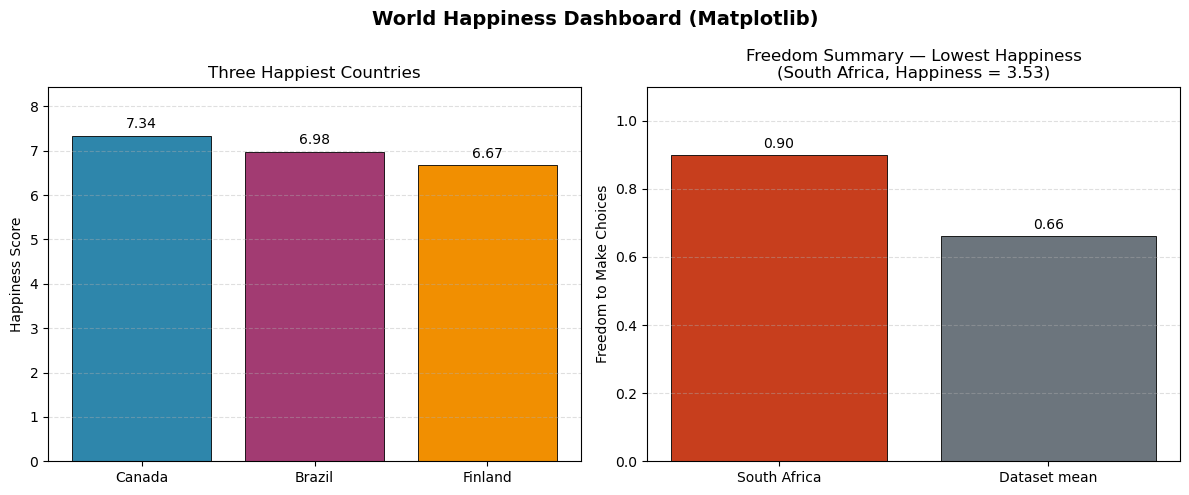

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle("World Happiness Dashboard (Matplotlib)", fontsize=14, fontweight="bold")

# Left: top 3 Happiness Scores
colours = ["#2E86AB", "#A23B72", "#F18F01"]
bars = axes[0].bar(
    top3["Country"],
    top3["Happiness_Score"],
    color=colours,
    edgecolor="black",
    linewidth=0.6,
)
axes[0].set_title("Three Happiest Countries")
axes[0].set_ylabel("Happiness Score")
axes[0].set_ylim(0, top3["Happiness_Score"].max() * 1.15)
axes[0].bar_label(bars, fmt="%.2f", padding=3)
axes[0].grid(axis="y", linestyle="--", alpha=0.4)

# Right: Freedom for lowest-happiness country vs mean
country = lowest["Country"]
freedom = float(lowest["Freedom_to_Make_Choices"])
happiness = float(lowest["Happiness_Score"])

freedom_bars = axes[1].bar(
    [country, "Dataset mean"],
    [freedom, mean_freedom],
    color=["#C73E1D", "#6C757D"],
    edgecolor="black",
    linewidth=0.6,
)
axes[1].set_title(
    f"Freedom Summary — Lowest Happiness\n({country}, Happiness = {happiness:.2f})"
)
axes[1].set_ylabel("Freedom to Make Choices")
axes[1].set_ylim(0, 1.1)
axes[1].bar_label(freedom_bars, fmt="%.2f", padding=3)
axes[1].grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()
fig.savefig(OUTPUT_DIR / "matplotlib_happiness_dashboard.png", dpi=150, bbox_inches="tight")
plt.show()

## 4. Plotly visualisations

Interactive charts — hover over bars for exact values.

In [7]:
# Interactive comparison of the three happiest countries
fig_top3 = px.bar(
    top3,
    x="Country",
    y="Happiness_Score",
    text="Happiness_Score",
    color="Country",
    title="Top 3 Happiest Countries — Interactive Comparison (Plotly)",
    labels={"Happiness_Score": "Happiness Score"},
    color_discrete_sequence=["#2E86AB", "#A23B72", "#F18F01"],
)
fig_top3.update_traces(texttemplate="%{text:.2f}", textposition="outside")
fig_top3.update_layout(
    yaxis_range=[0, top3["Happiness_Score"].max() * 1.2],
    template="plotly_white",
    showlegend=False,
    height=450,
)
fig_top3.write_html(OUTPUT_DIR / "plotly_top3_happiness.html", include_plotlyjs="cdn")
fig_top3.show()

In [8]:
# Full Plotly dashboard: top 3 Happiness + Freedom summary
fig_dash = make_subplots(
    rows=1,
    cols=2,
    subplot_titles=(
        "Three Happiest Countries — Happiness Score",
        f"Freedom Summary — {country} (Happiness = {happiness:.2f})",
    ),
    horizontal_spacing=0.12,
)

fig_dash.add_trace(
    go.Bar(
        x=top3["Country"],
        y=top3["Happiness_Score"],
        text=[f"{v:.2f}" for v in top3["Happiness_Score"]],
        textposition="outside",
        marker_color=["#2E86AB", "#A23B72", "#F18F01"],
        name="Happiness Score",
        hovertemplate="%{x}<br>Happiness Score: %{y:.2f}<extra></extra>",
    ),
    row=1,
    col=1,
)

fig_dash.add_trace(
    go.Bar(
        x=[country, "Dataset mean"],
        y=[freedom, mean_freedom],
        text=[f"{freedom:.2f}", f"{mean_freedom:.2f}"],
        textposition="outside",
        marker_color=["#C73E1D", "#6C757D"],
        name="Freedom",
        hovertemplate="%{x}<br>Freedom: %{y:.2f}<extra></extra>",
        showlegend=False,
    ),
    row=1,
    col=2,
)

fig_dash.update_yaxes(
    title_text="Happiness Score",
    range=[0, top3["Happiness_Score"].max() * 1.2],
    row=1,
    col=1,
)
fig_dash.update_yaxes(
    title_text="Freedom to Make Choices",
    range=[0, 1.15],
    row=1,
    col=2,
)
fig_dash.update_layout(
    title_text="World Happiness Dashboard (Plotly)",
    title_x=0.5,
    height=480,
    width=1000,
    template="plotly_white",
    showlegend=False,
    margin=dict(t=80, b=40),
)

fig_dash.write_html(OUTPUT_DIR / "plotly_happiness_dashboard.html", include_plotlyjs="cdn")
fig_dash.show()

## 5. Approach, findings, and chart choice

### Approach
1. Load the cleaned CSV and confirm there are no missing values.
2. Rank countries by `Happiness_Score` to get the top 3 and the lowest.
3. Visualise with **Matplotlib** (static PNG) and **Plotly** (interactive HTML / notebook charts).
4. For Freedom, compare the lowest-happiness country’s score with the dataset mean for context.

### Findings
| Rank | Country | Happiness Score |
|------|---------|-----------------|
| 1 | Canada | 7.34 |
| 2 | Brazil | 6.98 |
| 3 | Finland | 6.67 |

| Country | Happiness Score | Freedom | Dataset mean Freedom |
|---------|-----------------|---------|----------------------|
| South Africa | 3.53 | 0.90 | 0.66 |

South Africa has the **lowest Happiness Score**, but a **relatively high Freedom** score (above the sample mean). In this small sample, low happiness does not automatically mean low freedom.

### Which chart is most appropriate — and why?

A **vertical bar chart** is the best fit for this task.

| Chart | Why it fits / does not |
|-------|------------------------|
| **Bar chart (chosen)** | Compares a small number of **categories** (countries) on one **numeric** measure. Ranking and differences are easy to see. |
| Line chart | Better for trends over time; we have no time series here. |
| Pie / donut | Poor for precise comparison of close values (e.g. Brazil vs Finland). |
| Scatter | Better for relationships between two continuous variables. |

Bars work well in both Matplotlib (report/PNG) and Plotly (interactive hover).